In [71]:
# Install packages
!pip install scikit-surprise # for SVD

# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Display
from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))

# Time handling
from datetime import datetime, timedelta

# Recommendation system (SVD)
from surprise import Dataset, Reader, SVD

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep Learning (Neural Collaborative Filtering)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv('ratings_Electronics.csv',
                 names=['user_id', 'item_id', 'rating', 'timestamp'],
                        dtype={'rating': 'float32'},header=None,
                 on_bad_lines='skip',
                 low_memory=False
                 )
df.head()

,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


,user_id,item_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


**Analyzing data**

In [3]:
printmd("**Number of Rating**: {:,}".format(len(df)))
printmd("**Number of Users**: {:,}".format(df['user_id'].nunique()))
printmd("**Number of Products**: {:,}".format(df['item_id'].nunique()))
printmd(f"**Columns**: {df.columns.tolist()}")

**Number of Rating**: 7,824,482

**Number of Users**: 4,201,696

**Number of Products**: 476,002

**Columns**: ['user_id', 'item_id', 'rating', 'timestamp']

In [4]:
df.describe()['rating'].reset_index()

,index,rating
0,count,7.824482e+06
1,mean,4.012337e+00
2,std,1.448278e+00
3,min,1.000000e+00
4,25%,3.000000e+00
5,50%,5.000000e+00
6,75%,5.000000e+00
7,max,5.000000e+00


,index,rating
0,count,7.824482e+06
1,mean,4.012337e+00
2,std,1.448278e+00
3,min,1.000000e+00
4,25%,3.000000e+00
5,50%,5.000000e+00
6,75%,5.000000e+00
7,max,5.000000e+00


There is no rating below 1 because the rating is between 1 to 5.

In [5]:
# Now see if there are any NULL values.
df.isnull().sum()

,0
user_id,0
item_id,0
rating,0
timestamp,0


**Good to know there is no missing values.**

In [6]:
# Calculate the everyday rating
data_by_date = df.copy()
data_by_date.timestamp = pd.to_datetime(data_by_date.timestamp, unit='s') # dt.date
data_by_date = data_by_date.sort_values(
    by = "timestamp",
    ascending = False
).reset_index(drop=True)
printmd("**Number of Ratings each day:**")
data_by_date.groupby("timestamp")['rating'].count().tail(10).reset_index()

**Number of Ratings each day:**

,timestamp,rating
0,2014-07-14,9701
1,2014-07-15,6892
2,2014-07-16,5943
3,2014-07-17,4781
4,2014-07-18,4912
5,2014-07-19,4183
6,2014-07-20,4273
7,2014-07-21,5458
8,2014-07-22,5010
9,2014-07-23,695


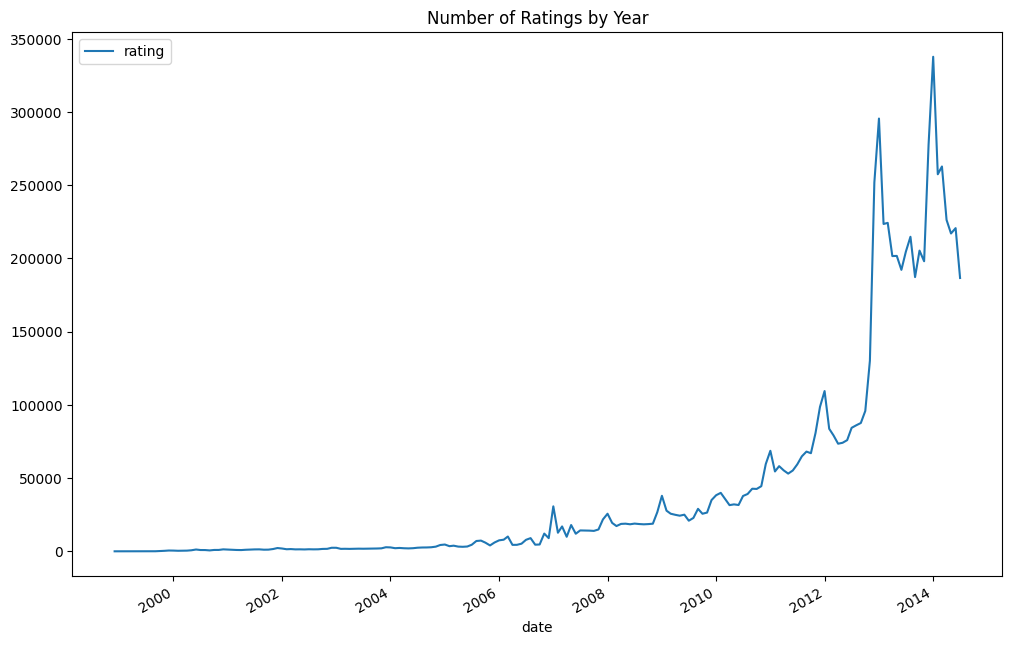

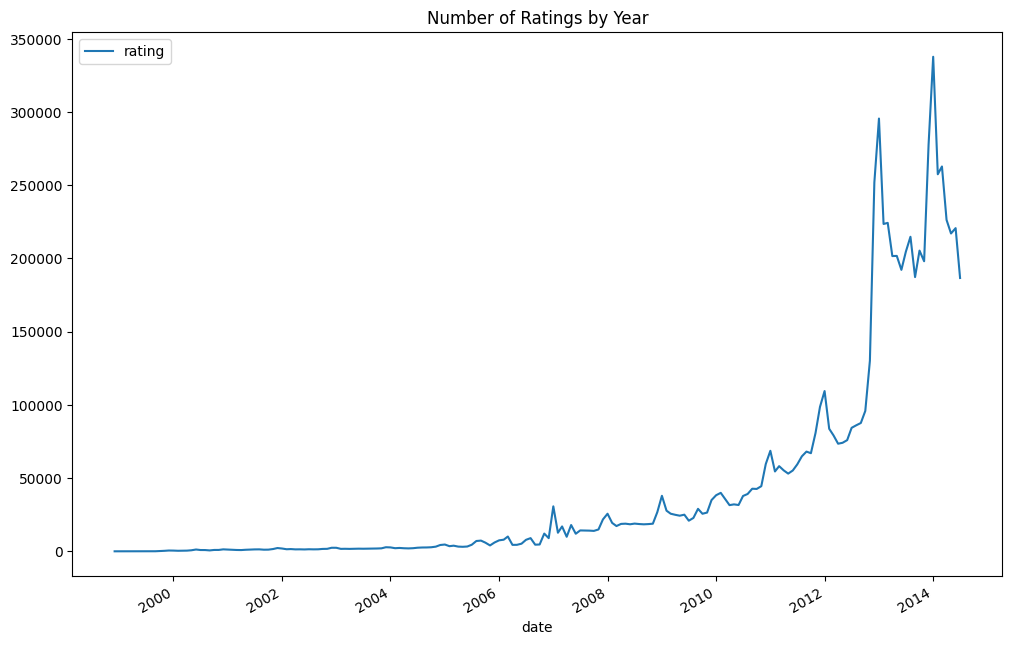

In [7]:
data_by_date["year"] = data_by_date.timestamp.dt.year
data_by_date["month"] = data_by_date.timestamp.dt.month
rating_by_year = data_by_date.groupby(["year","month"])['rating'].count().reset_index()
rating_by_year["date"] = pd.to_datetime(rating_by_year[["year","month"]].assign(day=1))
rating_by_year.plot(x="date", y="rating", figsize=(12,8))
plt.title("Number of Ratings by Year")
plt.show()

Rating VS. user

In [8]:
# Rating distribution
ratings = df["rating"].value_counts().sort_index()

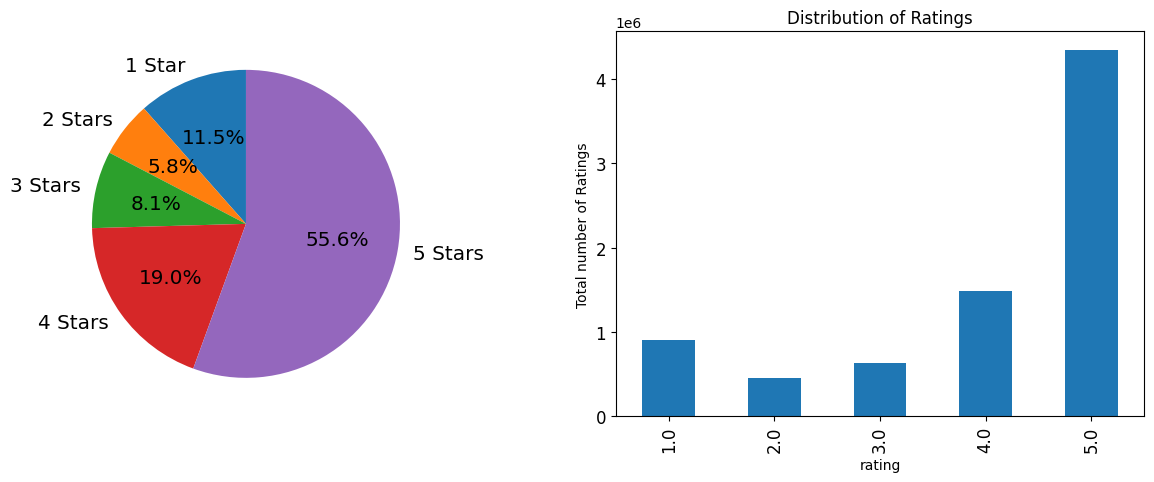

In [9]:
from matplotlib import legend
figsize = (15, 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
ratings.plot.pie(ax=ax1, y="rating", legend= False, autopct='%1.1f%%', startangle=90, fontsize= "x-large",
                 labels= ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"])
ax1.set_ylabel('')
ratings.plot.bar(ax=ax2, fontsize = "large")
ax2.set_ylabel('Total number of Ratings')
ax2.set(title = "Distribution of Ratings")

plt.show()

In [10]:
# Calculate number of ratings per person to analyze user activity
rating_by_user = df.groupby(by = 'user_id')['rating'].count().sort_values(ascending = False).reset_index()

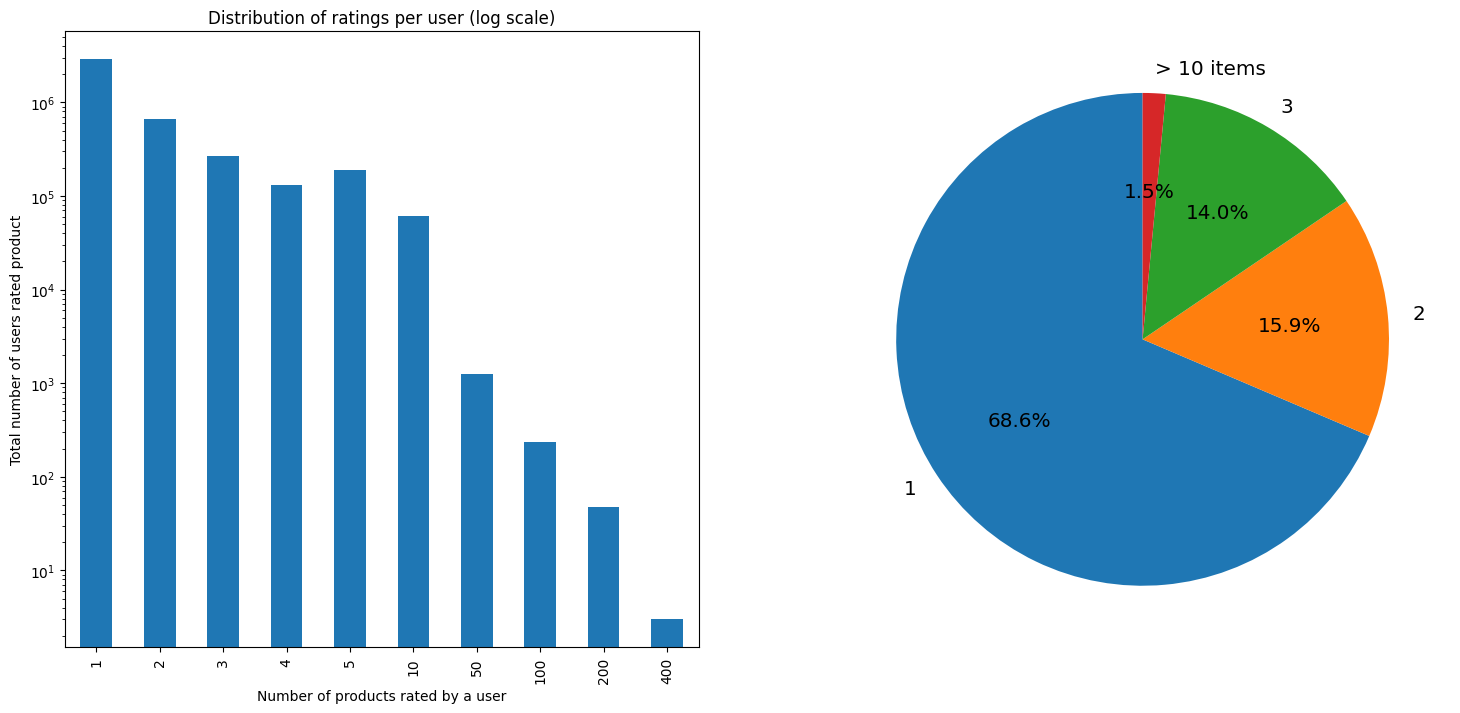

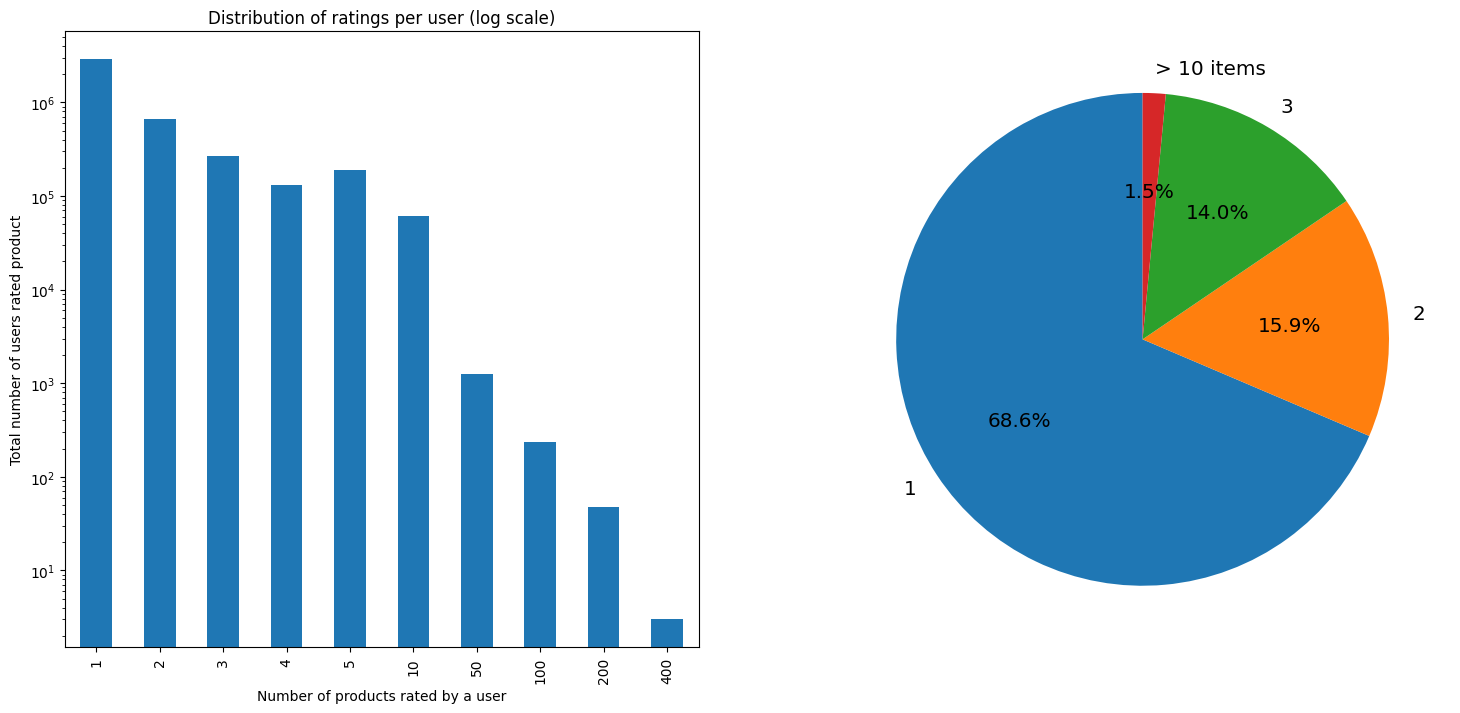

In [11]:
rating_hist, bins = np.histogram(rating_by_user['rating'], bins = [1, 2, 3, 4, 5, 10, 50, 100, 200, 400, 500])
rating_hist2, bins2 = np.histogram(rating_by_user['rating'], bins = [1, 2, 3, 10, 100000])

figsize = (18, 8)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

# Bar chart
pd.DataFrame({"Numbers of User": rating_hist, "Total Rates": bins[:-1]}).plot.bar(x="Total Rates", ax=ax1)
ax1.set(yscale="log")
ax1.set(ylabel="Total number of users rated product", xlabel="Number of products rated by a user")
ax1.set(title="Distribution of ratings per user (log scale)")
ax1.get_legend().remove()

pd.DataFrame({"Number of User": rating_hist2, "Total Rates":bins2[:-1]}).plot.pie(x="Total Rates", y="Number of User",
                                                                                  labels=[1, 2, 3, "> 10 items"], ax=ax2, legend=False, autopct='%1.1f%%', startangle=90, fontsize = "x-large")
ax2.set_ylabel('')
plt.show()

**Based on the plots, there are only 1.5% of users rated more than 10 products.**

Rating VS. Product

In [12]:
# Compute how many times ratings be rated
# rating_by_product = df.groupby(by = 'item_id')['rating'].count().sort_values(ascending = False).reset_index()
rating_by_product = df.groupby("item_id").agg({"user_id": "count", "rating": "mean"}).rename(columns={
    "user_id": "Number of Ratings",
    "rating": "Average Rating"
}).reset_index()

In [13]:
printmd("**Top 10 products by number of ratings:**")
rating_by_product.sort_values(by="Number of Ratings", ascending=False).reset_index(drop=True).head(10)

**Top 10 products by number of ratings:**

,item_id,Number of Ratings,Average Rating
0,B0074BW614,18244,4.491504
1,B00DR0PDNE,16454,3.931020
2,B007WTAJTO,14172,4.424005
3,B0019EHU8G,12285,4.754498
4,B006GWO5WK,12226,4.314657
5,B003ELYQGG,11617,4.392528
6,B003ES5ZUU,10276,4.704749
7,B007R5YDYA,9907,4.690926
8,B00622AG6S,9823,4.420136
9,B0002L5R78,9487,4.448614


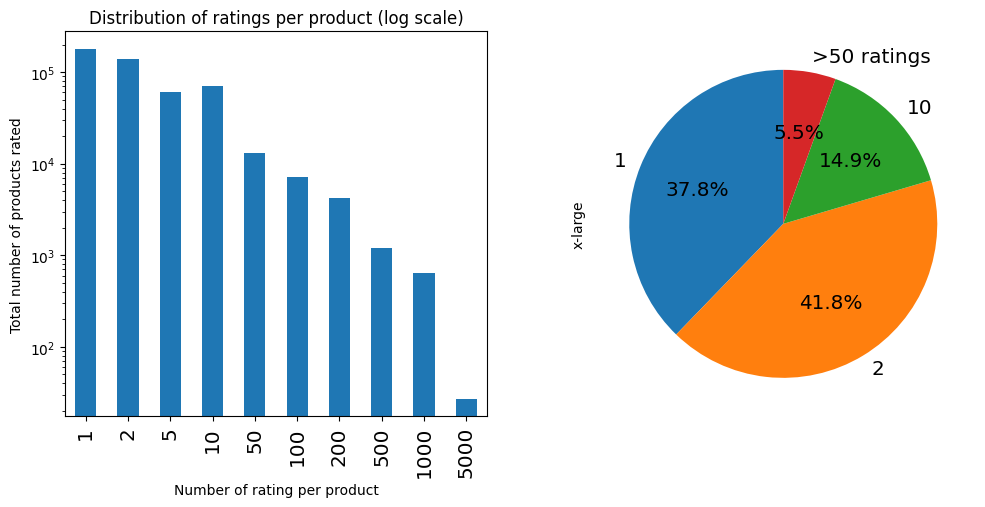

In [14]:
rating_hist, bins = np.histogram(rating_by_product['Number of Ratings'], bins = [1, 2, 5, 10, 50, 100, 200, 500, 1000, 5000, 100000])
rating_hist2, bins2 = np.histogram(rating_by_product['Number of Ratings'], bins = [1, 2, 10, 50, 100000])

figsize = (12, 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

pd.DataFrame({"Number of Products": rating_hist, "Total Rates": bins[:-1]}).plot.bar(x="Total Rates", ax=ax1)
ax1.set(yscale="log")
ax1.set(ylabel="Total number of products rated", xlabel="Number of rating per product")
ax1.set(title="Distribution of ratings per product (log scale)")
ax1.get_legend().remove()
[item.set_fontsize("x-large") for item in ax1.get_xticklabels()]

pd.DataFrame({"Number of User": rating_hist2, "Total Rates":bins2[:-1]}).plot.pie(x="Total Rates", y="Number of User",
                                                                                  labels=[1, 2, 10, ">50 ratings"], ax=ax2, legend = False,
                                                                                  autopct = "%1.1f%%", startangle = 90, fontsize = "x-large")
ax2.set(ylabel = "x-large")

plt.show()

**Only 5.5% of products rated by more than 50 people.**

Products by Average Rating

In [15]:
# Keep only product with enough ratings
# Remove products with very few ratings (not reliable)

cutoff = 50
top_rated = rating_by_product.loc[rating_by_product['Number of Ratings'] >= cutoff].sort_values(
    by = "Average Rating",
    ascending = False
).reset_index(drop=True)

In [16]:
printmd("**Top 5 products have the highest Ratings:**")
top_rated.head(5)

**Top 5 products have the highest Ratings:**

**Top 5 products have the highest Ratings:**

,item_id,Number of Ratings,Average Rating
0,B002E6R7NG,51,4.980392
1,B004I763AW,60,4.966667
2,B003J9QQWU,56,4.964286
3,B0043ZLFXE,90,4.955555
4,B000TMFYBO,64,4.953125


,item_id,Number of Ratings,Average Rating
0,B002E6R7NG,51,4.980392
1,B004I763AW,60,4.966667
2,B003J9QQWU,56,4.964286
3,B0043ZLFXE,90,4.955555
4,B000TMFYBO,64,4.953125


In [17]:
# Show how many products remain after cutoff
# Check statistics of filtered products
printmd("**With cutoff = {} we have only {:,} products.".format(cutoff, top_rated.shape[0]))
top_rated.describe()

**With cutoff = 50 we have only 26,226 products.

,Number of Ratings,Average Rating
count,26226.000000,26226.000000
mean,204.923092,3.980288
std,437.950769,0.527460
min,50.000000,1.127273
25%,67.000000,3.677881
50%,100.000000,4.074805
75%,188.000000,4.375000
max,18244.000000,4.980392


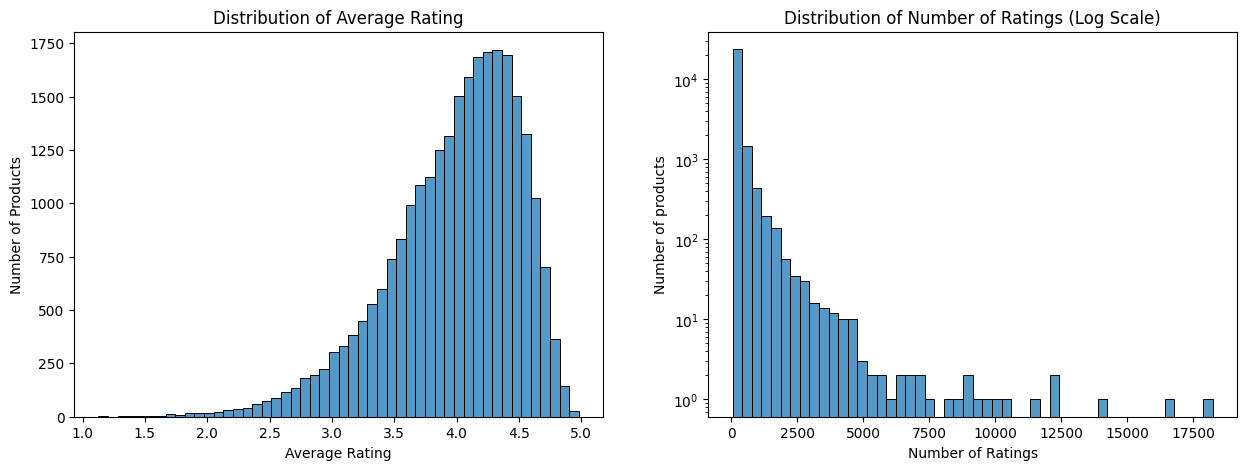

In [18]:
figsize = (15, 5)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
sns.histplot(data = top_rated["Average Rating"], bins = 50, ax = ax1)
ax1.set(title = "Distribution of Average Rating", ylabel = "Number of Products")

sns.histplot(data = top_rated["Number of Ratings"], bins = 50, ax = ax2)
ax2.set(title = "Distribution of Number of Ratings (Log Scale)")
ax2.set(yscale = "log", ylabel = "Number of products")

plt.show()

**Joint Graph

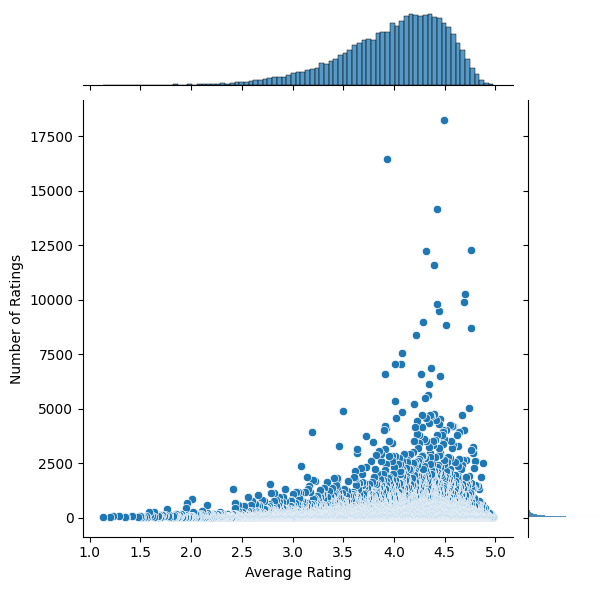

In [19]:
printmd("**Joint Graph")
sns.jointplot(x = 'Average Rating', y = 'Number of Ratings', data = top_rated);

**The average rating distribution shows that most products receive relatively high ratings, indicating a positive rating bias. Meanwhile, the number of ratings per product follows a long-tail distribution, where most products receive very few ratings while only a small number of products are highly popular. This highlights the sparsity of the dataset and the presence of cold-start challenges.**

**Recently Popular Items**

Top products rated during periord of 30 days

In [20]:
begin_date = data_by_date.timestamp[0] - timedelta(days=30)
data_by_date30 = data_by_date.loc[data_by_date.timestamp >= begin_date]
products_30days = data_by_date30.groupby(["item_id"]).agg({"rating": ["mean", "count"]}).droplevel(axis = 1, level=0).reset_index()

<h3 style= 'color:red'> Top Products by Number of Ratings </h3>

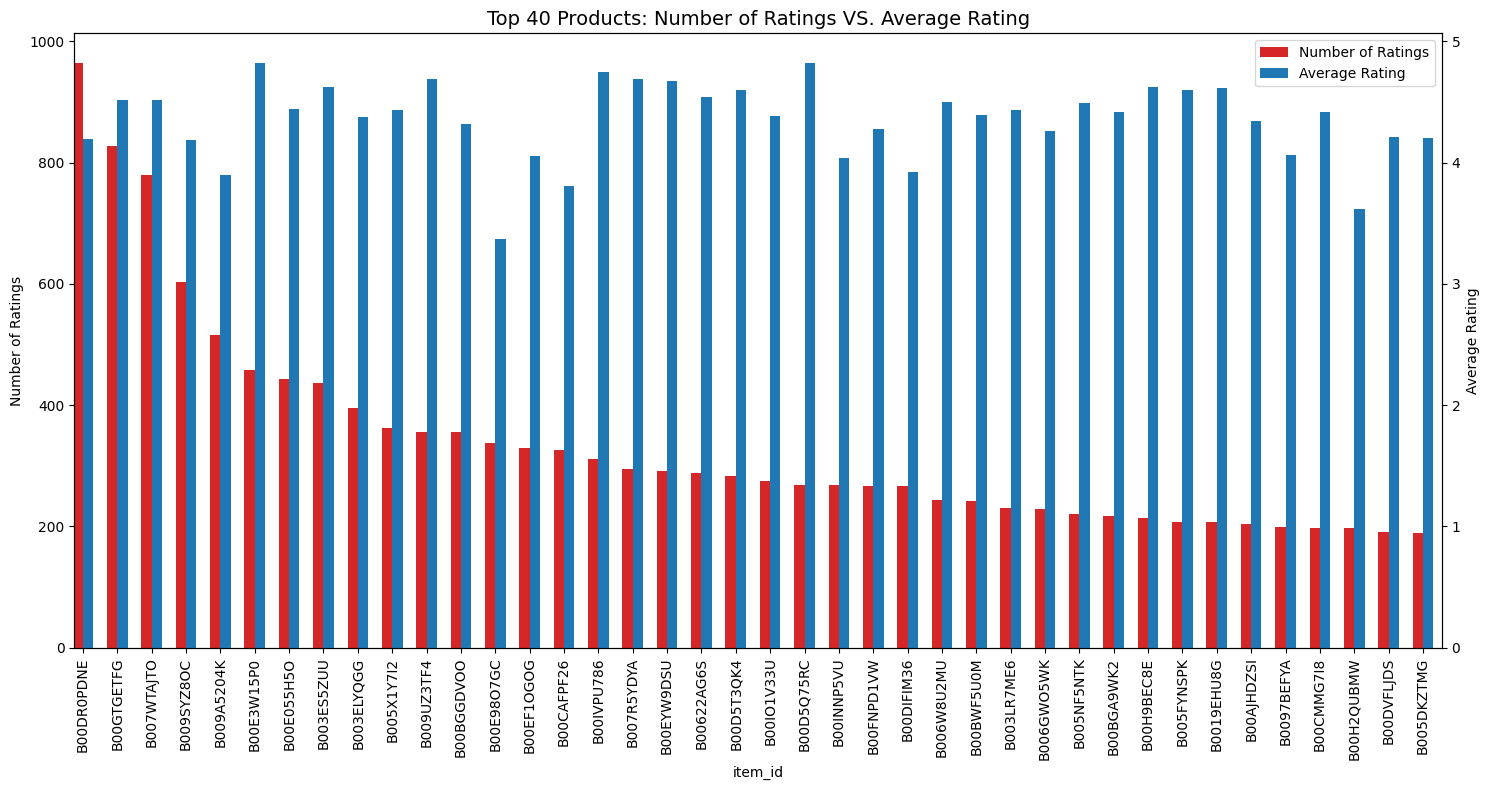

In [21]:
top_rated = products_30days.sort_values("count", ascending = False).head(40)

printmd("<h3 style= 'color:red'> Top Products by Number of Ratings </h3>")
figsize = (15, 8)
fig0, ax1 = plt.subplots(figsize = figsize)
ax2 = ax1.twinx()
top_rated.plot(kind = 'bar', x = 'item_id', y = 'count',
               ax = ax1, align = 'edge', color = 'tab:red', width = -0.3, legend = False)
top_rated.plot(kind = 'bar', x = 'item_id', y = 'mean',
               ax = ax2, align = 'edge', color = 'tab:blue', width = 0.3, legend = False)

ax1.set_title("Top 40 Products: Number of Ratings VS. Average Rating", fontsize = 14)

legend_elements = [
    Patch(facecolor='tab:red', label='Number of Ratings'),
    Patch(facecolor='tab:blue', label='Average Rating')
]
ax1.legend(handles=legend_elements, loc = 'upper right')
ax1.set_ylabel("Number of Ratings")
ax2.set_ylabel("Average Rating")
plt.tight_layout()
plt.show()

**This chart compares product popularity and customer satisfaction for the top 40 products.While some products receive a large number of ratings, their average scores are not always the highest. This suggests that highly popular products are not necessarily the most preferred by customers. From a business perspective, this insight highlights the importance of balancing both popularity and customer satisfaction when making product recommendations.**

<h3 style= 'color:red'> List of top products by Average Rating </h3>

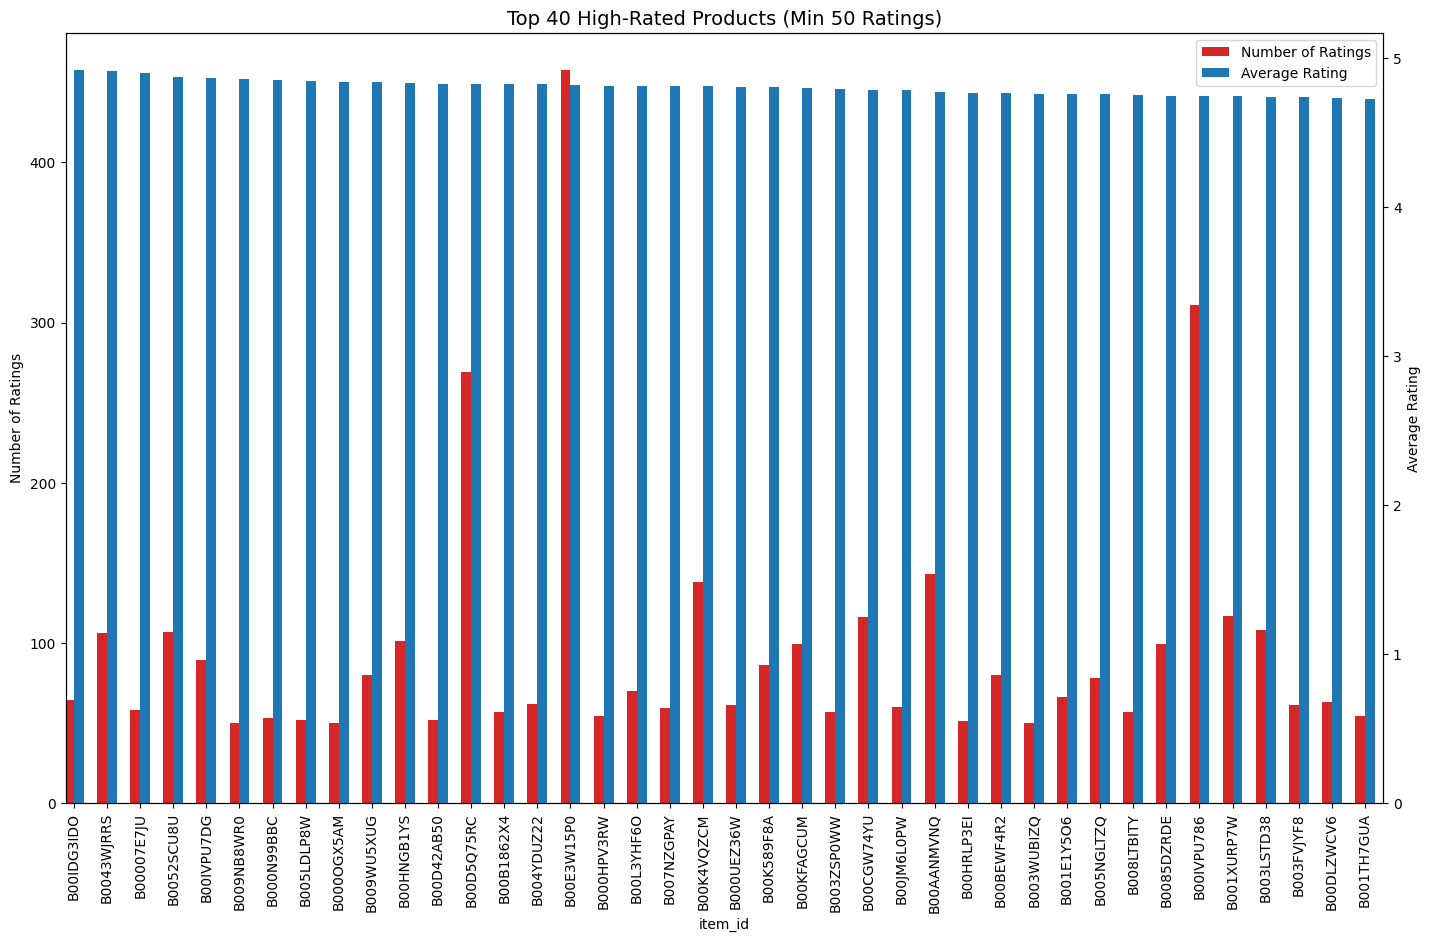

In [22]:
# Find those high-rated products
top_rated = products_30days.loc[products_30days["count"] >= 50].sort_values("mean", ascending = False).head(40)

printmd("<h3 style= 'color:red'> List of top products by Average Rating </h3>")
figsize = (17, 10)
fig0, ax1 = plt.subplots(figsize = figsize)
ax2 = ax1.twinx()
top_rated.plot(kind = 'bar', x = 'item_id', y = 'count',
               ax = ax1, align = 'edge', color = 'tab:red', width = -0.3, legend = False)
top_rated.plot(kind = 'bar', x = 'item_id', y = 'mean',
               ax = ax2, align = 'edge', color = 'tab:blue', width = 0.3, legend = False)

ax1.set_title("Top 40 High-Rated Products (Min 50 Ratings)", fontsize = 14)

legend_elements = [
    Patch(facecolor='tab:red', label='Number of Ratings'),
    Patch(facecolor='tab:blue', label='Average Rating')
]
ax1.legend(handles=legend_elements, loc = 'upper right')
ax1.set_ylabel("Number of Ratings")
ax2.set_ylabel("Average Rating")

plt.tight_layout
plt.show()

**This chart highlights the top high-rated products with at least 50 reviews. While all selected products have strong average ratings, only a few receive a large number of reviews. Most high-rated products remain relatively less popular, indicating that many high-quality items are underexposed. This suggests an opportunity to promote these hidden items and improve recommendation diversity.**

***Based on the exploratory analysis, we identified three major challenges in the dataset: sparsity, cold-start users, and unreliable average ratings for products with very few reviews. To address these issues, we designed a multi-stage recommendation strategy.***

***To address the challenges identified in the exploratory analysis, we implemented multiple recommendation approaches. A weighted popularity model was used to handle cold-start scenarios, as it provides reliable recommendations when user interaction history is limited. A recent-popularity model was introduced to capture time-sensitive trends and newly popular products.***

***For personalized recommendations, we applied matrix factorization using SVD, which is well-suited for sparse datasets and efficiently captures latent user-item relationships. Additionally, we implemented Neural Collaborative Filtering (NCF) to model non-linear interactions between users and items, allowing for more flexible and expressive recommendations.***

***Finally, we combined these approaches using a hybrid recommendation strategy with fallback mechanisms to improve robustness and address different recommendation scenarios.***

In [52]:
# Keep only items with enough interactions
# Many products have only a few ratings, so their average rating is inreliable.
# To reduce noise, we only keep items that have more than 50ratings.

# Count how many ratings each item has received
item_counts = df.groupby('item_id')['rating'].count()

# Minimum number of ratings required for an item to be kept
cutoff = 50

# Filter items with more than 50 ratings
valid_items = item_counts[item_counts > cutoff].index

# Filter the dataset to remain only valid items
df_filtered = df[df['item_id'].isin(valid_items)]

print("Original data:", df.shape)
print("Filtered data:", df_filtered.shape)

Original data: (7824482, 4)
Filtered data: (5350913, 4)


**Separate the dataset into train data and test data**

In [24]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    df_filtered,
    test_size=0.2,
    random_state=42
)

**Popularity Baseline**

We compute the average rating and rating count for each item to find the most popular products for those cold start users.

In [25]:
# Build a weighted popularity baseline model
# A simple average rating is not enough, because some products have very high ratings from only a few users.
# We use weighted rating to balance:
#  1. product average rating
#  2. product rating count
# This makes the baseline recommendation more reliable.
# ==============================================================================

# Global average rating across all products in the training
# This is used as a reference score in the weighted rating formula
C = train_data['rating'].mean()

# Here m = 50 means we give more trust to products with at least 50 ratings
m = 50

# Compute basic statistics for each item
# rating_count = how many users rated this item
# rating_mean  = average rating of this item
item_stats = train_data.groupby('item_id').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
).reset_index()

# Compute weighted rating score
# Formula:
# weighted_score = (v / (v + m)) * R + (m / (v + m)) * C
# where:
#   v = number of ratings for the item
#   R = average rating of the item
#   C = global average rating
#   m = minimum rating threshold
#
# Interpretation:
# - If an item has many ratings, its own average rating matters more
# - If an item has few ratings, the global average matters more
# This helps avoid overvaluing items with very few but very high ratings
item_stats['weighted_score'] = (
    (item_stats['rating_count'] / (item_stats['rating_count'] + m)) * item_stats['rating_mean']
    + (m / (item_stats['rating_count'] + m)) * C
)

baseline_top = item_stats.sort_values(
    'weighted_score',
    ascending=False
)

baseline_top.head(10)

,item_id,rating_count,rating_mean,weighted_score
13413,B0043WJRRS,1981,4.885916,4.865674
11756,B003FVVMS0,1521,4.859961,4.834617
8877,B0029N3U8K,542,4.878229,4.809431
19835,B007SZ0E1K,353,4.909348,4.804425
15260,B004S4R5CK,1244,4.833601,4.803851
19754,B007R5YGO2,1023,4.833822,4.797934
24330,B00D5Q75RC,2092,4.808317,4.790935
22105,B009NB8WR0,1167,4.820051,4.788975
8465,B001W28L2Y,642,4.844237,4.787837
8463,B001W26TIW,602,4.833887,4.774821


In [26]:
# Create dictionary for fast lookup
baseline_dict = dict(
    zip(
        baseline_top['item_id'],
        baseline_top['weighted_score']
    )
)

# Function to predict rating
def baseline_predict(row):
    return baseline_dict.get(row['item_id'], C)

In [27]:
# Prediction on test data
test_data['baseline_pred'] = test_data.apply(baseline_predict, axis=1)

In [28]:
# RMSE evaluation
print("====Baseline Evaluation====")
rmse_baseline = np.sqrt(
    mean_squared_error(
        test_data['rating'],
        test_data['baseline_pred']
    )
)

print("Baseline RMSE:", rmse_baseline)

# MAE evaluation
mae_baseline = mean_absolute_error(
    test_data['rating'],
    test_data['baseline_pred']
)

print("Baseline MAE:", mae_baseline)

====Baseline Evaluation====
Baseline RMSE: 1.2743110942435767
Baseline MAE: 1.0059526033206811


**The baseline model achieved an RMSE of 1.27 and MAE of 1.01, indicating that popularity-based recommendations alone are not sufficiently accurate. This is expected because the baseline model does not consider user preferences and relies solely on overall product ratings. Therefore, more personalized recommendation approaches are required to improve prediction performance.**

**Trending Items**

In [29]:
# ==================================================
# Step 4. Recent Popularity Baseline
# Why:
# Some products may become popular recently.
# We use recent ratings (last 30 days) to capture trending products.
# ==================================================

from datetime import timedelta

# Convert timestamp to datetime
train_data['timestamp'] = pd.to_datetime(
    train_data['timestamp'],
    unit='s'
)

# Find the latest date in dataset
latest_date = train_data['timestamp'].max()

# Define recent period (last 30 days)
begin_date = latest_date - timedelta(days=30)

# Filter recent data
recent_data = train_data[
    train_data['timestamp'] >= begin_date
]

In [30]:
# Compute statistics for recent data
recent_stats = recent_data.groupby('item_id').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
).reset_index()

In [31]:
# Global average rating
C_recent = recent_data['rating'].mean()

# Minimum votes
m = 50

# Weighted rating formula
recent_stats['weighted_score'] = (
    (recent_stats['rating_count'] /
     (recent_stats['rating_count'] + m)) * recent_stats['rating_mean']
    +
    (m / (recent_stats['rating_count'] + m)) * C_recent
)

recent_top = recent_stats.sort_values(
    'weighted_score',
    ascending=False
)

recent_top.head(10)

,item_id,rating_count,rating_mean,weighted_score
15382,B00E3W15P0,366,4.819672,4.735609
15019,B00D5Q75RC,222,4.806306,4.680195
6820,B0043WJRRS,79,4.949367,4.628009
13212,B009UZ3TF4,288,4.704861,4.618382
16361,B00IVPU786,245,4.714286,4.613604
16398,B00K4VQZCM,113,4.823009,4.607443
8561,B0052SCU8U,95,4.852632,4.600091
5757,B003ES5ZUU,353,4.651558,4.585640
11192,B007R5YDYA,238,4.680672,4.583379
16227,B00HNGB1YS,83,4.843373,4.571527


In [32]:
# Create dictionary
recent_dict = dict(
    zip(
        recent_top['item_id'],
        recent_top['weighted_score']
    )
)

# Prediction function
def recent_predict(row):
    return recent_dict.get(row['item_id'], C_recent)

# Predict on test data
test_data['recent_pred'] = test_data.apply(
    recent_predict,
    axis=1
)

In [33]:
rmse_recent = np.sqrt(
    mean_squared_error(
        test_data['rating'],
        test_data['recent_pred']
    )
)

mae_recent = mean_absolute_error(
    test_data['rating'],
    test_data['recent_pred']
)

print("====Recent Baseline Evaluation====")
print("Recent RMSE:", rmse_recent)
print("Recent MAE:", mae_recent)

====Recent Baseline Evaluation====
Recent RMSE: 1.3352876742352744
Recent MAE: 1.0434036655600407
====Recent Baseline Evaluation====
Recent RMSE: 1.3352876742352744
Recent MAE: 1.0434036655600407


**The recent popularity model achieved slightly worse performance compared to the baseline model. This suggests that product ratings in this dataset are relatively stable over time, and recent trends do not significantly improve prediction accuracy. Therefore, popularity-based approaches alone are insufficient, and personalized recommendation models are required.**

In [34]:
# Prepare data for SVD model
# SVD requires data in Surprise format


reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    train_data[['user_id','item_id','rating']],
    reader
)

In [35]:
# Train SVD model
# SVD learns latent factors for users and items
trainset = data.build_full_trainset()

model_svd = SVD()

model_svd.fit(trainset)

In [36]:
# Predict on test data
testset = list(
    zip(
        test_data['user_id'],
        test_data['item_id'],
        test_data['rating']
    )
)

predictions = [
    model_svd.predict(uid, iid, r_ui=r)
    for (uid, iid, r) in testset
]

In [37]:
# Evaluation
from surprise import accuracy

print("====SVD Evaluation====")

rmse_svd = accuracy.rmse(predictions)
mae_svd = accuracy.mae(predictions)

====SVD Evaluation====
RMSE: 1.2688
MAE:  0.9932


**The SVD model captures latent relationships between users and items, allowing the system to generate personalized recommendations.**

**However, the performance improvement is limited, which may be due to the sparse nature of the dataset and limited user interaction history. To further improve recommendation performance, we next explore a KNN - based collaborative filtering model.**

Neural Collaborative Filtering Model

In [38]:
# Sample smaller dataset to speed up deep learning
sample_size = 300000

df_sample = df_filtered.sample(
    n=sample_size,
    random_state=42
)

print("Sample size:", df_sample.shape)

Sample size: (300000, 4)


In [39]:
# Train / Test Split
# We split the sampled dataset into training and testing sets
# to properly evaluate model performance on unseen data.

train_data, test_data = train_test_split(
    df_sample,
    test_size=0.2,
    random_state=42
)

print("Train:", train_data.shape)
print("Test:", test_data.shape)

Train: (240000, 4)
Test: (60000, 4)


In [40]:
# Encode user and item ids

# Neural networks require numerical input.
# Therefore, we convert user_id and item_id into integer indices.

user_ids = train_data['user_id'].astype("category").cat.codes
item_ids = train_data['item_id'].astype("category").cat.codes

n_users = user_ids.nunique()
n_items = item_ids.nunique()

ratings = train_data['rating'].values

In [41]:
# Build Neural Collaborative Filtering Model

embedding_size = 20

# User input
user_input = Input(shape=(1,))
user_embedding = Embedding(
    input_dim=n_users,
    output_dim=embedding_size
)(user_input)

user_vec = Flatten()(user_embedding)

# Item input
item_input = Input(shape=(1,))
item_embedding = Embedding(
    input_dim=n_items,
    output_dim=embedding_size
)(item_input)

item_vec = Flatten()(item_embedding)

# Combine
concat = Concatenate()([user_vec, item_vec])

# Hidden layers
dense = Dense(64, activation='relu')(concat)
dense = Dense(32, activation='relu')(dense)

# Output
output = Dense(1)(dense)

# Model
model = Model(
    inputs=[user_input, item_input],
    outputs=output
)

model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae']
)

model.summary()

Model: "functional"

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 20)     │  4,522,700 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 20)     │    502,760 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 20)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 20)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,030,197 (19.19 MB)

 Trainable params: 5,030,197 (19.19 MB)

 Non-trainable params: 0 (0.00 B)

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 20)     │  4,522,700 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 20)     │    502,760 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 20)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 20)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      2,624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,030,197 (19.19 MB)

 Trainable params: 5,030,197 (19.19 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train model

model.fit(
    [user_ids, item_ids],
    ratings,
    epochs=3,
    batch_size=512,
    verbose=1
)

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 4.0732 - mae: 1.5277
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 1.1320 - mae: 0.8077
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.3839 - mae: 0.4451


In [43]:
# Prepare test data

test_user = test_data['user_id'].astype("category").cat.codes
test_item = test_data['item_id'].astype("category").cat.codes

test_rating = test_data['rating'].values

In [45]:
# Evaluate Neural CF Model

predictions = model.predict([test_user, test_item])

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

rmse_ncf = np.sqrt(mean_squared_error(test_rating, predictions))
mae_ncf = mean_absolute_error(test_rating, predictions)

print("==== Neural CF Evaluation ====")
print("NeuralCF RMSE:", rmse_ncf)
print("NeuralCF MAE:", mae_ncf)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
==== Neural CF Evaluation ====
NeuralCF RMSE: 1.7907887755055207
NeuralCF MAE: 1.2922500371932983


In [46]:
# Compare Model Performance

results = {
    "Model": ["Baseline", "Recent", "SVD", "NeuralCF"],
    "RMSE": [
        rmse_baseline,
        rmse_recent,
        rmse_svd,
        rmse_ncf
    ],
    "MAE": [
        mae_baseline,
        mae_recent,
        mae_svd,
        mae_ncf
    ]
}

results_df = pd.DataFrame(results)

results_df.sort_values("RMSE")

,Model,RMSE,MAE
2,SVD,1.268796,0.993165
0,Baseline,1.274311,1.005953
1,Recent,1.335288,1.043404
3,NeuralCF,1.790789,1.292250


Hybrid model

In [59]:
# Use SVD as main model
# Use Baseline as fallback for cold-start
# threshold: number of interactions required to use SVD

threshold = 3

def hybrid_predict(user, item):

    # Count user interactions
    user_count = train_data[train_data['user_id'] == user].shape[0]

    # fallback → baseline
    if user_count < threshold:
        return baseline_dict.get(item, train_data['rating'].mean())

    # main model → SVD
    else:
        return model_svd.predict(user, item).est

In [64]:
# Hybrid Predictions
test_sample = test_data.sample(3000, random_state=42)

hybrid_preds = []

for row in test_sample.itertuples():
    pred = hybrid_predict(row.user_id, row.item_id)
    hybrid_preds.append(pred)

In [65]:
# Evaluation
rmse_hybrid = np.sqrt(
    mean_squared_error(test_sample['rating'], hybrid_preds)
)

mae_hybrid = mean_absolute_error(
    test_sample['rating'], hybrid_preds
)

print("==== Hybrid Evaluation ====")
print("Hybrid RMSE:", rmse_hybrid)
print("Hybrid MAE:", mae_hybrid)

==== Hybrid Evaluation ====
Hybrid RMSE: 1.2706858856879892
Hybrid MAE: 1.0041484832763672


In [67]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Recent", "SVD", "NeuralCF", "Hybrid"],
    "RMSE": [
        rmse_baseline,
        rmse_recent,
        rmse_svd,
        rmse_ncf,
        rmse_hybrid
    ],
    "MAE": [
        mae_baseline,
        mae_recent,
        mae_svd,
        mae_ncf,
        mae_hybrid
    ]
})

comparison.sort_values("RMSE")

,Model,RMSE,MAE
2,SVD,1.268796,0.993165
4,Hybrid,1.270686,1.004148
0,Baseline,1.274311,1.005953
1,Recent,1.335288,1.043404
3,NeuralCF,1.790789,1.292250


***To further improve recommendation performance, we implemented a hybrid model that combines the SVD model with a popularity-based baseline as a fallback strategy. This hybrid approach is commonly used in real-world recommendation systems to address cold-start users while maintaining personalized recommendations for active users.***

***Due to the large size of the dataset and computational constraints, we evaluated the hybrid model using a random sample of 3,000 interactions. This sampling approach allows us to efficiently compare model performance while preserving the overall data distribution. Such sampling is also commonly used in industry for rapid experimentation and model comparison.***

***The evaluation results show that the SVD model achieved the best performance, with an RMSE of 1.2688 and MAE of 0.9932. The hybrid model performed similarly, with an RMSE of 1.2707 and MAE of 1.0041, while the baseline model achieved comparable results. This indicates that the hybrid approach did not significantly improve performance over the SVD model.***

***This result suggests that the SVD model already captures sufficient user-item interaction patterns, and the fallback strategy provides limited additional benefit in this dataset. Therefore, we selected the SVD model as the final recommendation model due to its superior performance and simpler implementation.***

Next, we generate top-N recommendations using the SVD model.

In [54]:
# Get all unique items
# We need to predict ratings for all items to recommend the top items to a specific user.

all_items = df_filtered['item_id'].unique()

In [55]:
# We choose a random user to generate recommendations

user_id = np.random.choice(test_data['user_id'].unique())

In [56]:
# Predict ratings for all items and rank them to recommend top items

predictions = []

for item in all_items:

    pred = model_svd.predict(
        user_id,
        item
    ).est

    predictions.append((item, pred))

In [50]:
# Sort items by predicted rating

predictions.sort(
    key=lambda x: x[1],
    reverse=True
)

In [51]:
printmd("Top 5 recommended products for User {}: ".format(user_id))

for item, _ in predictions[:5]:
    print(item)

Top 5 recommended products for User ADJ6L71KJHY2O: 

B00013J89K
B0001F347K
B000IJY8DS
B000JMJWV2
B001VKY7XE


***After comparing multiple recommendation models, the SVD model achieved the best performance in terms of RMSE and MAE. Therefore, we used the SVD model to generate personalized recommendations. For a selected user, the model successfully identified the top five items with the highest predicted ratings. This demonstrates that the recommendation system can effectively capture user preferences and provide meaningful personalized recommendations.***